In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from huggingface_hub import hf_hub_download, login
import os
from dotenv import load_dotenv # You might need: pip install python-dotenv
from huggingface_hub import login

In [3]:
load_dotenv() # This loads the variables from the .env file
token = os.getenv("HF_TOKEN")

login(token=token) 

# Define Standard UNSW-NB15 Columns (Since raw files have no headers)
columns = [
    'srcip', 'sport', 'dstip', 'dport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 
    'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 
    'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 
    'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label'
]

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
print("Downloading raw files from Hugging Face...")
filenames = ["UNSW-NB15_1.csv", "UNSW-NB15_2.csv", "UNSW-NB15_3.csv", "UNSW-NB15_4.csv"]
dataframes = []

for f in filenames:
    file_path = hf_hub_download(
        repo_id="AdnanShownok/unsw_nb15_ids",
        filename=f,
        repo_type="dataset"
    )
    # Read CSV (low_memory=False prevents mixed-type warnings)
    df_temp = pd.read_csv(file_path, header=None, names=columns, low_memory=False)
    dataframes.append(df_temp)
    print(f"Loaded {f}")

# Combine into one
df_full = pd.concat(dataframes, ignore_index=True)
print(f"Total Dataset Shape: {df_full.shape}")

Loaded UNSW-NB15_1.csv
Loaded UNSW-NB15_2.csv
Loaded UNSW-NB15_3.csv
Loaded UNSW-NB15_4.csv
Total Dataset Shape: (2540047, 49)


In [5]:
print("Cleaning and Encoding data...")

# Fix Target Column 'attack_cat'
df_full['attack_cat'] = df_full['attack_cat'].fillna('Normal')
df_full['attack_cat'] = df_full['attack_cat'].str.strip() # Remove extra spaces

# Encode All Object/Text Columns (IPs, Proto, etc.)
# We do NOT drop any columns, we encode them all.
le_dict = {} # To store encoders if needed later
for col in df_full.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col].astype(str))
    le_dict[col] = le

# Prepare X (Features) and y (Target)
X = df_full.drop(columns=['attack_cat', 'Label'])
y = df_full['attack_cat'] # Already encoded above

Cleaning and Encoding data...


In [6]:
selector_model = XGBClassifier(
    n_estimators=50, 
    tree_method='hist', 
    random_state=42, 
    n_jobs=-1
)
selector_model.fit(X, y)

# Extract Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': selector_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_20_features = importance_df['Feature'].head(20).tolist()
print(f"Selected Features: {top_20_features}")

Selected Features: ['ct_state_ttl', 'sbytes', 'dttl', 'sttl', 'ct_dst_sport_ltm', 'swin', 'synack', 'dport', 'dbytes', 'ct_srv_dst', 'dwin', 'service', 'sport', 'srcip', 'sloss', 'smeansz', 'ct_dst_src_ltm', 'dmeansz', 'proto', 'Ltime']


In [7]:
print("Training Final Model on Top 20 Features...")

# Filter Data
X_final = df_full[top_20_features]
y_final = y

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Train Classifier
final_model = XGBClassifier(
    n_estimators=100, 
    tree_method='hist', 
    random_state=42, 
    n_jobs=-1
)
final_model.fit(X_train, y_train)

Training Final Model on Top 20 Features...


KeyboardInterrupt: 

In [ ]:
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n### FINAL ACCURACY: {acc * 100:.2f}% ###")

# Get Class Names for Report (to fix the 'int has no len' error)
# We look at the LabelEncoder for 'attack_cat' to get names
target_names = [str(c) for c in le_dict['attack_cat'].classes_]
print(classification_report(y_test, y_pred, target_names=target_names))

# SAVE TO DISK
print("Saving model and features...")
joblib.dump(final_model, 'ids_model.joblib')
with open('ids_features.json', 'w') as f:
    json.dump(top_20_features, f)

print("DONE! Files 'ids_model.joblib' and 'ids_features.json' are ready.")


### FINAL ACCURACY: 98.38% ###
                precision    recall  f1-score   support

      Analysis       0.71      0.08      0.15       535
      Backdoor       0.86      0.10      0.18       359
     Backdoors       0.20      0.02      0.03       107
           DoS       0.44      0.30      0.36      3271
      Exploits       0.65      0.87      0.75      8905
       Fuzzers       0.75      0.63      0.69      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.93      0.77      0.84      2798
     Shellcode       0.78      0.85      0.82       302
         Worms       0.71      0.43      0.54        35

      accuracy                           0.98    508010
     macro avg       0.73      0.55      0.58    508010
  weighted avg       0.98      0.98      0.98    508010

Saving model and features...
DONE! Files 'ids_model.joblib' and 'ids_features.json' are ready.


Starting comparison on 2032037 rows. Hold tight!

Training Decision Tree...
--> Decision Tree Accuracy: 98.21% (Took 4.1s)
Training Random Forest...
--> Random Forest Accuracy: 98.38% (Took 26.8s)
Training Logistic Regression...
--> Logistic Regression Accuracy: 87.35% (Took 292.4s)

FINAL RESULTS: WHICH MODEL IS BEST?
                  Algorithm  Accuracy Time (seconds)
1             Random Forest  0.983784      26.768777
3  XGBoost (Current Winner)  0.983766            N/A
0             Decision Tree  0.982063       4.085557
2       Logistic Regression  0.873518     292.379981


C:\Users\adnan\AppData\Local\Temp\ipykernel_1552\3863824648.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Algorithm", data=comparison_df, palette="viridis")


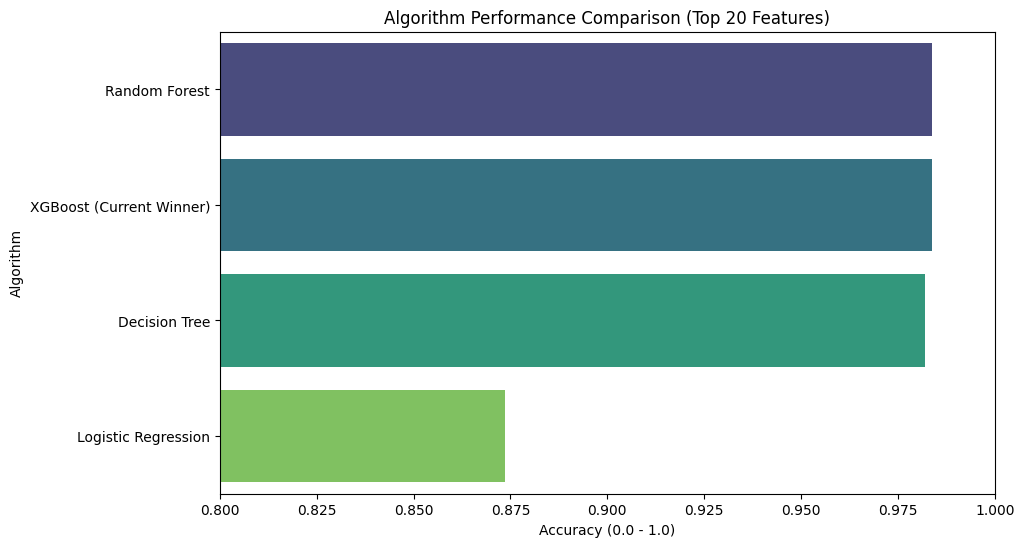

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import time

# 1. Setup the Models
# n_jobs=-1 means "use all CPU cores" (Critical for Random Forest on 2M rows)
models_to_test = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1, random_state=42)
}

results_list = []

print(f"Starting comparison on {len(X_train)} rows. Hold tight!\n")

# 2. The Training Loop
for name, model in models_to_test.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_temp = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred_temp)
    elapsed = time.time() - start_time
    
    results_list.append({
        "Algorithm": name,
        "Accuracy": acc,
        "Time (seconds)": elapsed
    })
    print(f"--> {name} Accuracy: {acc*100:.2f}% (Took {elapsed:.1f}s)")

# 3. Add your XGBoost result (from previous step) for comparison
# Assuming 'final_model' from the master script is still in memory
xgb_pred = final_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
results_list.append({
    "Algorithm": "XGBoost (Current Winner)", 
    "Accuracy": xgb_acc,
    "Time (seconds)": "N/A"
})

# 4. Create the Comparison Table
comparison_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)

print("\n===========================================")
print("FINAL RESULTS: WHICH MODEL IS BEST?")
print("===========================================")
print(comparison_df)

# 5. Visualize the Winner
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Algorithm", data=comparison_df, palette="viridis")
plt.xlim(0.8, 1.0) # Zoom in on the 80%-100% range to see differences
plt.title("Algorithm Performance Comparison (Top 20 Features)")
plt.xlabel("Accuracy (0.0 - 1.0)")
plt.show()

In [ ]:
import shap
import numpy as np
import time
import joblib

# 1. Setup
# Use the model you just trained (final_model)
# Use the FULL dataset (X_final) which has all 2.5M rows and Top 20 features
print(f"Initializing SHAP on {X_final.shape[0]} rows... this will be heavy.")

# 2. Initialize the Fast TreeExplainer
# This is optimized for XGBoost/RandomForest
explainer = shap.TreeExplainer(final_model)

# 3. Calculate SHAP Values (The Heavy Step)
start_time = time.time()

# check_additivity=False prevents crashes on minor precision errors
print("Calculating SHAP values... Go get a coffee, this will take a while.")
shap_values = explainer.shap_values(X_final, check_additivity=False)

end_time = time.time()
print(f"Calculation Complete! Time taken: {(end_time - start_time)/60:.2f} minutes")

# 4. Save the SHAP values to disk
# These are valuable! Save them so you never have to run this again.
joblib.dump(shap_values, 'shap_values_full.joblib')
print("SHAP values saved to 'shap_values_full.joblib'")

Initializing SHAP on 2540047 rows... this will be heavy.
Calculating SHAP values... Go get a coffee, this will take a while.
Calculation Complete! Time taken: 34.79 minutes
SHAP values saved to 'shap_values_full.joblib'


In [ ]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.preprocessing import LabelEncoder
from huggingface_hub import hf_hub_download

print("Recovering X_final from disk... (using cached files)")

# 1. Load the Top 20 Feature List (so we know which columns to keep)
try:
    with open('ids_features.json', 'r') as f:
        top_20_features = json.load(f)
    print(f"Features loaded: {top_20_features}")
except FileNotFoundError:
    print("Error: 'ids_features.json' not found. Please run the Master Script first.")

# 2. Load the Raw Data again (Fast if cached)
columns = [
    'srcip', 'sport', 'dstip', 'dport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 
    'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 
    'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 
    'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label'
]

filenames = ["UNSW-NB15_1.csv", "UNSW-NB15_2.csv", "UNSW-NB15_3.csv", "UNSW-NB15_4.csv"]
dataframes = []

# Download/Load
for f in filenames:
    file_path = hf_hub_download(
        repo_id="AdnanShownok/unsw_nb15_ids",
        filename=f,
        repo_type="dataset"
    )
    df_temp = pd.read_csv(file_path, header=None, names=columns, low_memory=False)
    dataframes.append(df_temp)

df_full = pd.concat(dataframes, ignore_index=True)

# 3. Re-Encode Data (CRITICAL: SHAP needs numbers, not strings)
# We apply the same transformation as the Master Script
df_full['attack_cat'] = df_full['attack_cat'].fillna('Normal').str.strip()

for col in df_full.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col].astype(str))

# 4. Recreate X_final
X_final = df_full[top_20_features]

print(f"Success! X_final restored with shape: {X_final.shape}")


Recovering X_final from disk... (using cached files)
Features loaded: ['ct_state_ttl', 'sbytes', 'dttl', 'sttl', 'ct_dst_sport_ltm', 'swin', 'synack', 'dport', 'dbytes', 'ct_srv_dst', 'dwin', 'service', 'sport', 'srcip', 'sloss', 'smeansz', 'ct_dst_src_ltm', 'dmeansz', 'proto', 'Ltime']
Success! X_final restored with shape: (2540047, 20)


Loaded SHAP values from disk.
Plotting 20000 points (Representative Sample)...
Saved to 'shap_summary_final.png'


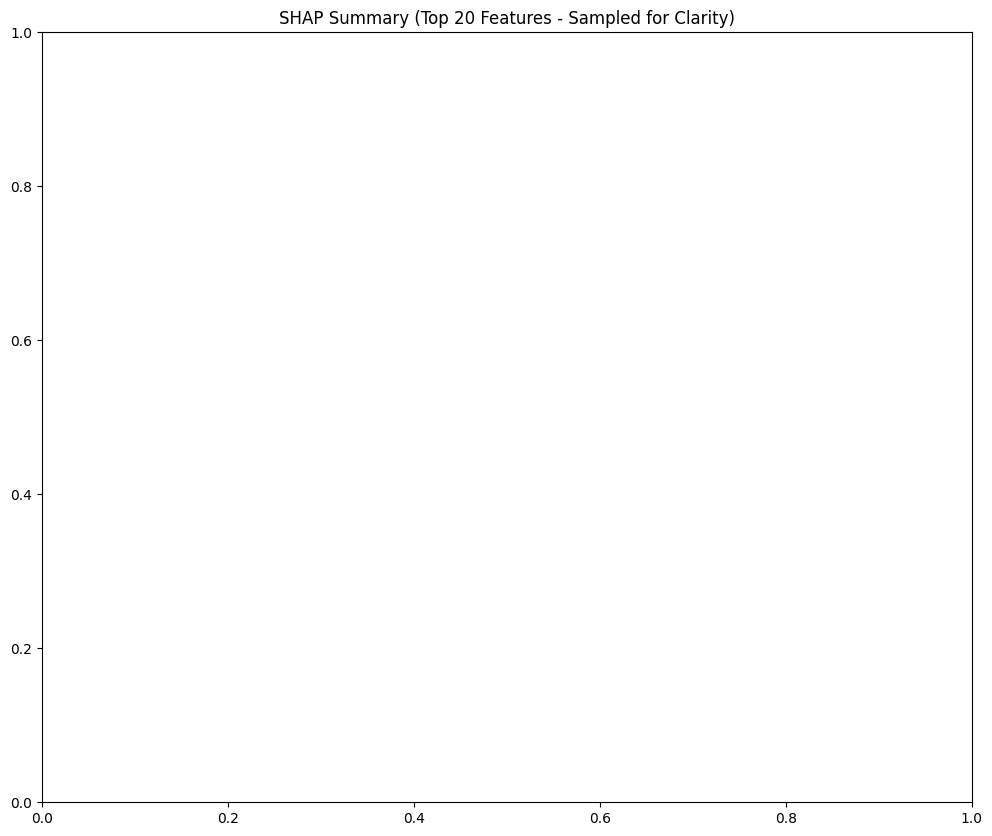

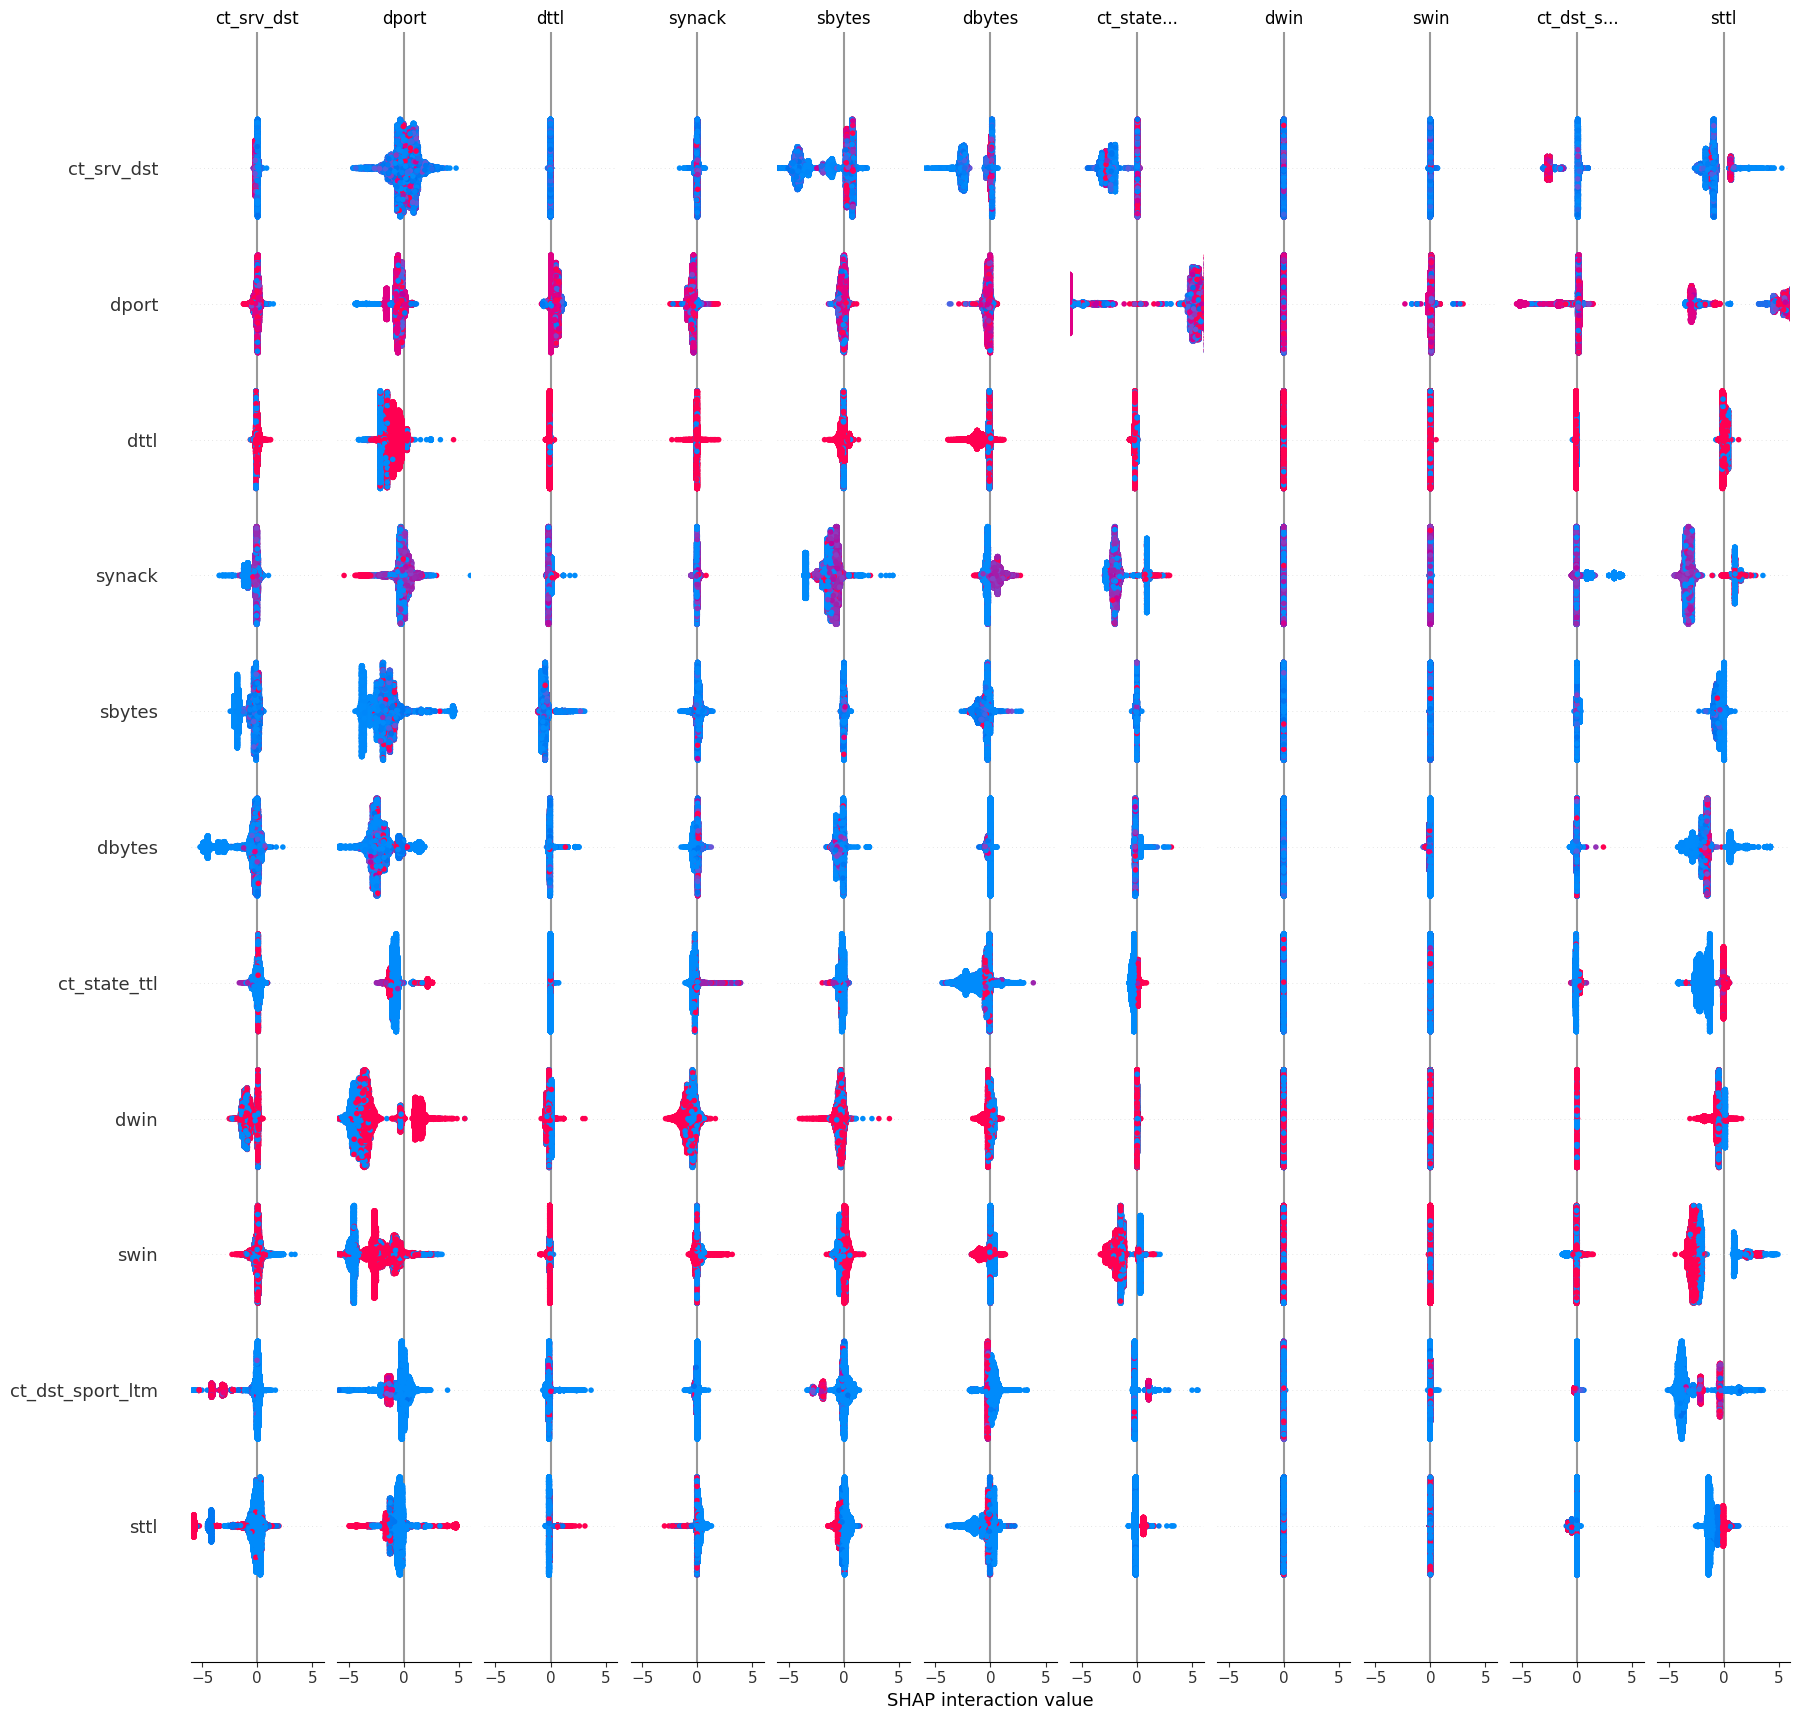

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import shap

# 1. Load the data (If you lost it from memory due to the crash)
# If 'shap_values' and 'X_final' are still in memory, skip these two load lines.
try:
    shap_values = joblib.load('shap_values_full.joblib')
    print("Loaded SHAP values from disk.")
except:
    print("Using shap_values currently in memory.")

# 2. Downsample for Plotting (The Fix)
# We take 20,000 random indices. This is plenty to show the distribution clearly.
N_ROWS = 20000 

if shap_values.shape[0] > N_ROWS:
    # Create random indices
    indices = np.random.choice(shap_values.shape[0], N_ROWS, replace=False)
    
    # Slice both the values and the data so they match
    shap_values_sample = shap_values[indices]
    X_sample = X_final.iloc[indices]
else:
    # If you have less than 20k rows, use them all
    shap_values_sample = shap_values
    X_sample = X_final

print(f"Plotting {len(X_sample)} points (Representative Sample)...")

# 3. Generate the Plot
plt.figure(figsize=(12, 10))
plt.title("SHAP Summary (Top 20 Features - Sampled for Clarity)")

shap.summary_plot(
    shap_values_sample, 
    X_sample, 
    max_display=20, 
    alpha=0.5,  # Slight transparency to see overlapping dots
    show=False
)

# 4. Save safely
plt.savefig("shap_summary_final.png", dpi=300, bbox_inches='tight')
print("Saved to 'shap_summary_final.png'")
plt.show()

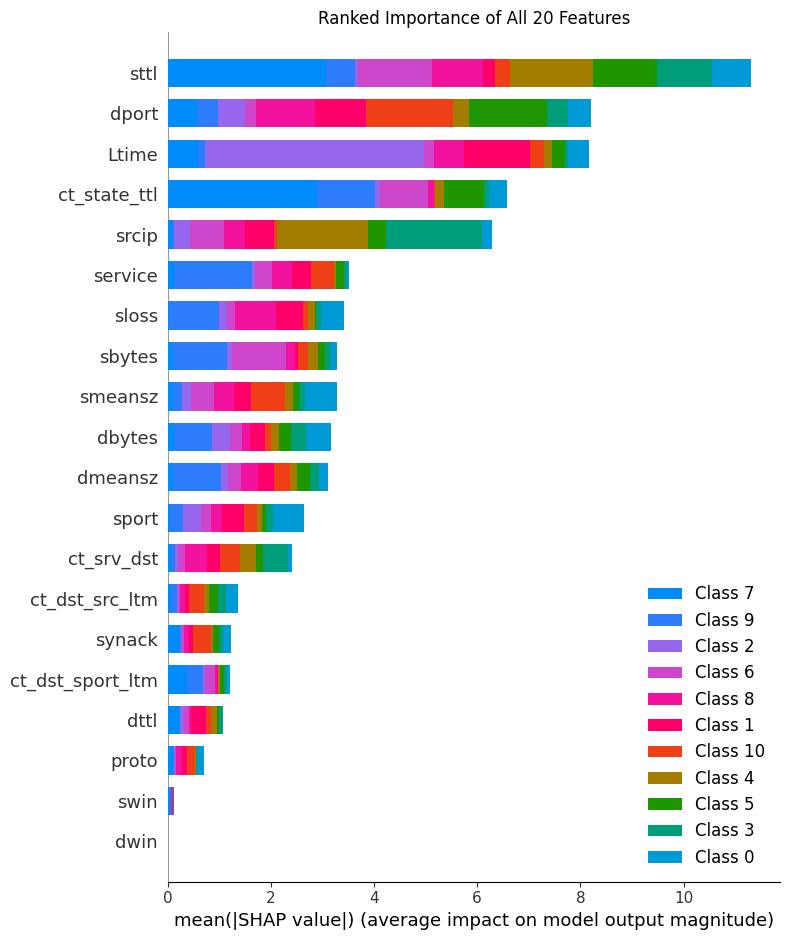

In [ ]:
plt.figure(figsize=(10, 12))
plt.title("Ranked Importance of All 20 Features")

shap.summary_plot(
    shap_values_sample, 
    X_sample, 
    plot_type="bar", 
    max_display=20, # Show all 20
    show=False
)

plt.tight_layout()
plt.show()

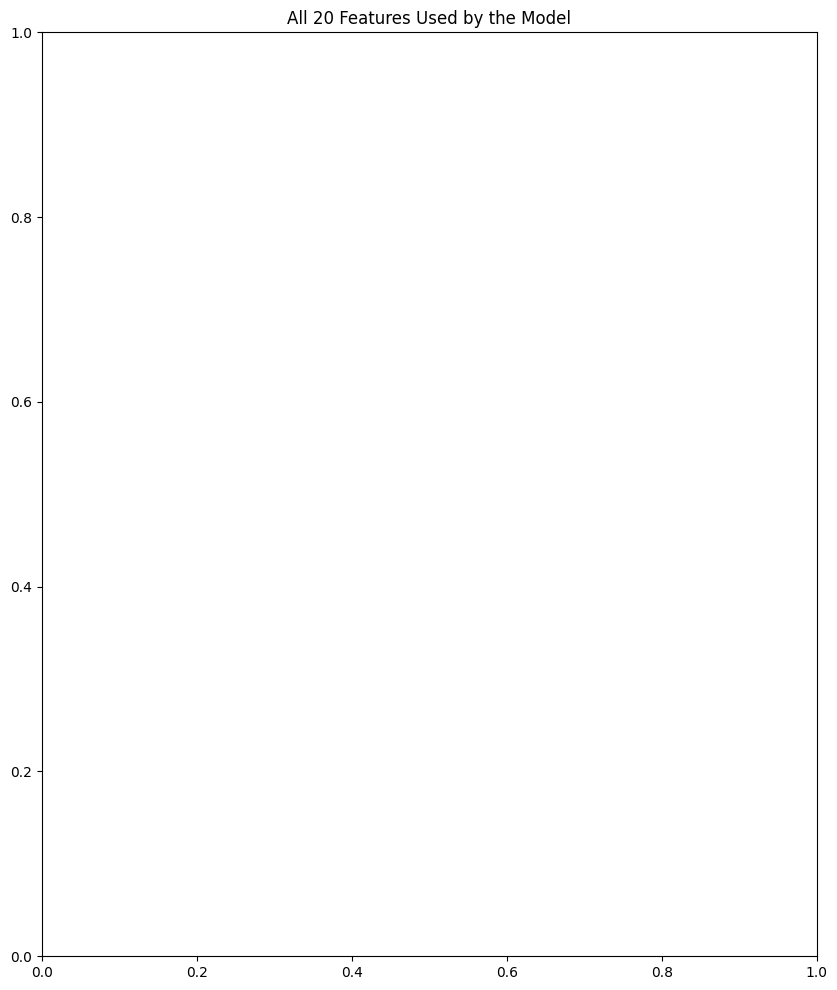

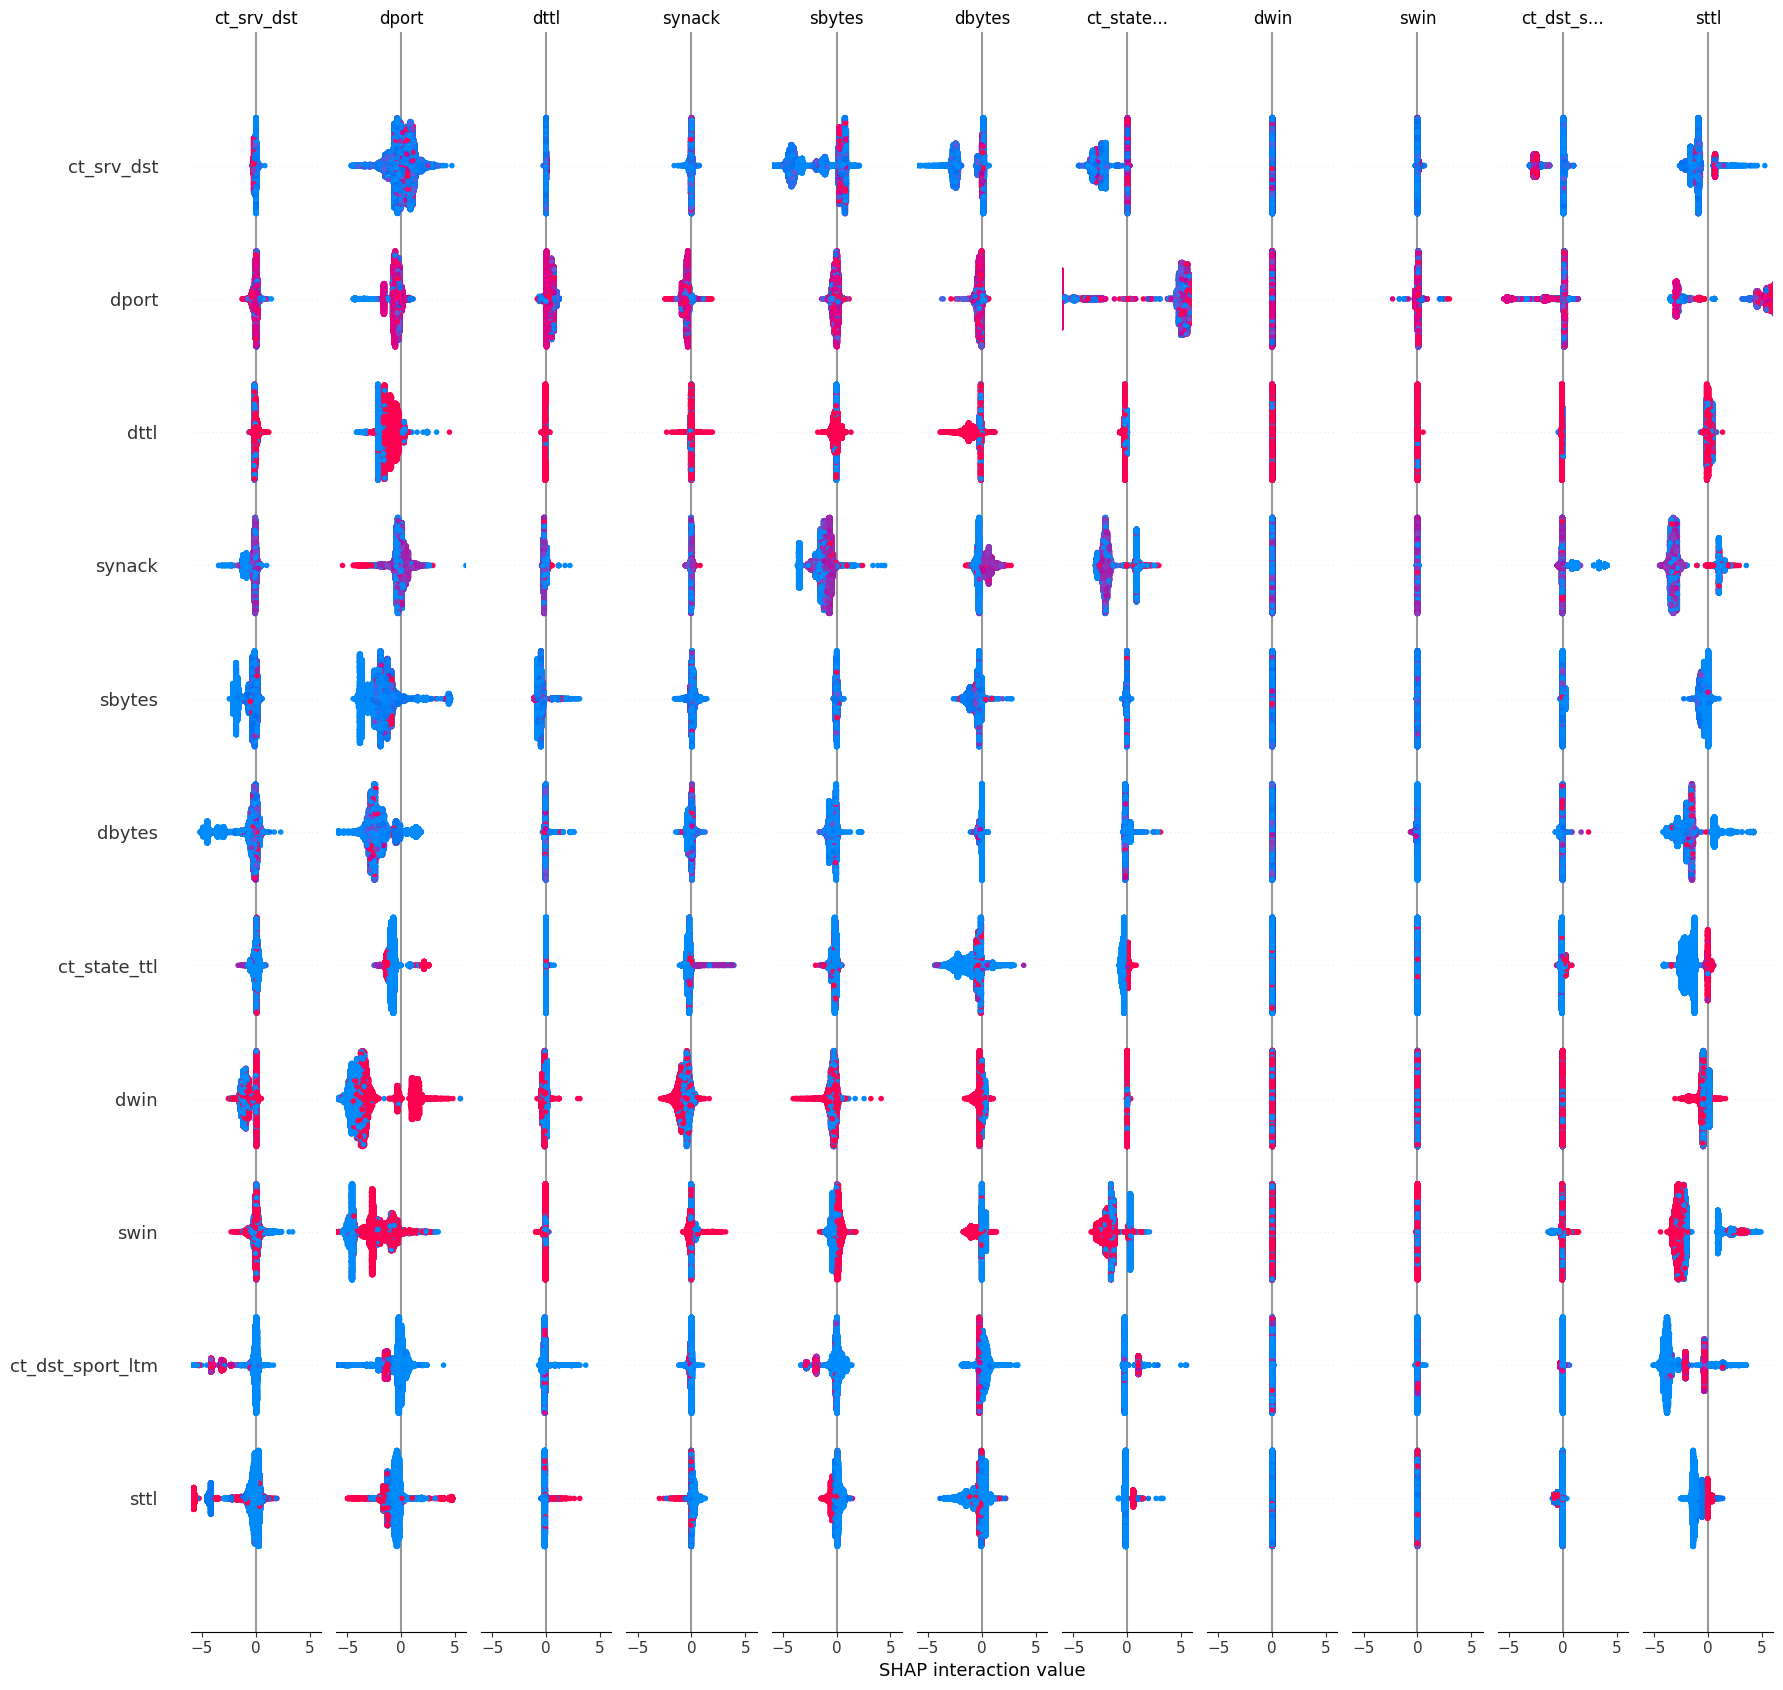

In [ ]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 12)) # Taller figure to fit all 20 rows
plt.title("All 20 Features Used by the Model")

# The 'Beeswarm' plot lists everything vertically
shap.summary_plot(
    shap_values_sample, 
    X_sample, 
    max_display=20,  # FORCE it to show top 20
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Total Rows in memory: {len(df_full)}")
# If the output is 2,540,044, then you have the full, merged dataset.

Total Rows in memory: 2540047


In [ ]:
# 1. Restore y_final from the dataframe you just loaded
y_final = df_full['attack_cat']

# 2. Now run the upload code again
print("Combining features and target...")
df_upload = X_final.copy()
df_upload['label'] = y_final 

print("Converting to Hugging Face Dataset format...")
from datasets import Dataset
hf_dataset = Dataset.from_pandas(df_upload)

# 3. Upload
repo_name = "AdnanShownok/unsw_nb15_processed_top20" # Change this name if you want
print(f"Uploading to {repo_name}...")
hf_dataset.push_to_hub(repo_name)

print("SUCCESS! Dataset uploaded.")

Combining features and target...
Converting to Hugging Face Dataset format...
Uploading to AdnanShownok/unsw_nb15_processed_top20...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

SUCCESS! Dataset uploaded.


In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict
from huggingface_hub import login

# 1. Login (Just to be safe)
login()

# 2. Prepare the Data
# Combine Features and Target into one DataFrame for storage
print("Combining features and target...")
df_upload = X_final.copy()
df_upload['label'] = y_final  # Add the target column (we call it 'label' by convention)

# 3. Convert to Hugging Face Dataset Object
# This format is much faster and more efficient than CSV
print("Converting to Hugging Face Dataset format...")
hf_dataset = Dataset.from_pandas(df_upload)

# 4. (Optional but Recommended) Split into Train/Test on the Hub
# This way, anyone who downloads it gets the splits automatically
# We use a 80% Train / 20% Test split
dataset_split = hf_dataset.train_test_split(test_size=0.2, seed=42)

# 5. Push to Hugging Face
# Give it a specific name so you know it's the processed version
repo_name = "AdnanShownok/unsw_nb15_processed_top20"

print(f"Uploading to {repo_name}... this might take a few minutes.")
dataset_split.push_to_hub(repo_name)

print("SUCCESS!")
print(f"View your dataset here: https://huggingface.co/datasets/{repo_name}")

Combining features and target...


NameError: name 'y_final' is not defined

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print(f"Starting 5-Fold Cross-Validation on {len(X_final)} rows...")
print("This trains the model 5 separate times. Please wait...")

# 1. Configure the Cross-Validation
# 'Stratified' ensures every fold has the same % of Attack vs Normal
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run CV
# We use the XGBoost model you defined earlier
scores = cross_val_score(
    final_model, 
    X_final, 
    y_final, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1  # Use all CPUs
)

# 3. Print Results
print("\n### Cross-Validation Results ###")
print(f"Individual Scores: {scores}")
print(f"Average Accuracy:  {np.mean(scores) * 100:.4f}%")
print(f"Standard Deviation: {np.std(scores) * 100:.4f}%")

Starting 5-Fold Cross-Validation on 2540047 rows...
This trains the model 5 separate times. Please wait...

### Cross-Validation Results ###
Individual Scores: [0.98384284 0.98384284 0.98366171 0.98360856 0.98362431]
Average Accuracy:  98.3716%
Standard Deviation: 0.0105%


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier
import numpy as np
import time

print(f"Starting 5-Fold Cross-Validation for LightGBM on {len(X_final)} rows...")

# 1. Configure LightGBM
# We use the same settings as before (fast and accurate)
lgb_cv_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=40,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 2. Configure the Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Run CV and Measure Time
start_time = time.time()

scores_lgb = cross_val_score(
    lgb_cv_model, 
    X_final, 
    y_final, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1
)

end_time = time.time()

# 4. Print Results
print("\n### LightGBM Cross-Validation Results ###")
print(f"Individual Scores: {scores_lgb}")
print(f"Average Accuracy:  {np.mean(scores_lgb) * 100:.4f}%")
print(f"Standard Deviation: {np.std(scores_lgb) * 100:.4f}%")
print(f"Total Time Taken:   {end_time - start_time:.2f} seconds")

Starting 5-Fold Cross-Validation for LightGBM on 2540047 rows...

### LightGBM Cross-Validation Results ###
Individual Scores: [0.97262652 0.97453987 0.97118161 0.97665789 0.95518977]
Average Accuracy:  97.0039%
Standard Deviation: 0.7649%
Total Time Taken:   248.99 seconds
